# Convolutional Neural Networks
---
In this notebook, we train a **CNN** to classify images from the CIFAR-10 database.

The images in this database are small color images that fall into one of ten classes; some example images are pictured below.

<img src='notebook_ims/cifar_data.png' width=70% height=70% />

In [1]:
import time
import torch
import numpy as np

num_threads = 24
# Device types: cpu, xpu, cuda
device_type = "xpu"
# how many samples per batch to load
batch_size = 20

---
## Load and Augment the [Data](http://pytorch.org/docs/stable/torchvision/datasets.html)

Downloading may take a minute. We load in the training and test data, split the training data into a training and validation set, then create DataLoaders for each of these sets of data.

#### Augmentation

In this cell, we perform some simple [data augmentation](https://medium.com/nanonets/how-to-use-deep-learning-when-you-have-limited-data-part-2-data-augmentation-c26971dc8ced) by randomly flipping and rotating the given image data. We do this by defining a torchvision `transform`, and you can learn about all the transforms that are used to pre-process and augment data, [here](https://pytorch.org/docs/stable/torchvision/transforms.html).

#### TODO: Look at the [transformation documentation](https://pytorch.org/docs/stable/torchvision/transforms.html); add more augmentation transforms, and see how your model performs.

This type of data augmentation should add some positional variety to these images, so that when we train a model on this data, it will be robust in the face of geometric changes (i.e. it will recognize a ship, no matter which direction it is facing). It's recommended that you choose one or two transforms.

In [2]:
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

# percentage of training set to use as validation
valid_size = 0.2

# convert data to a normalized torch.FloatTensor
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # randomly flip and rotate
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

# choose the training and test datasets
train_data = datasets.CIFAR10('data', train=True,
                              download=True, transform=transform)
test_data = datasets.CIFAR10('data', train=False,
                             download=True, transform=transform)

# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders (combine dataset and sampler)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_threads)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_threads)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_threads)

# specify the image classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

Files already downloaded and verified
Files already downloaded and verified


### Visualize a Batch of Training Data

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image

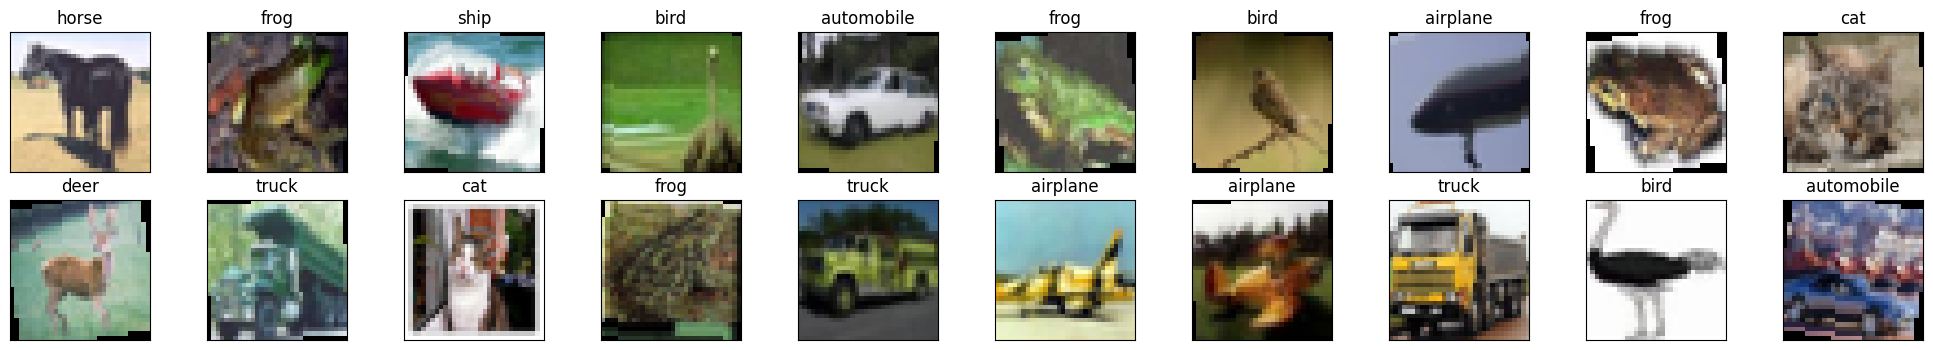

In [4]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
# display 20 images
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

### View an Image in More Detail

Here, we look at the normalized red, green, and blue (RGB) color channels as three separate, grayscale intensity images.

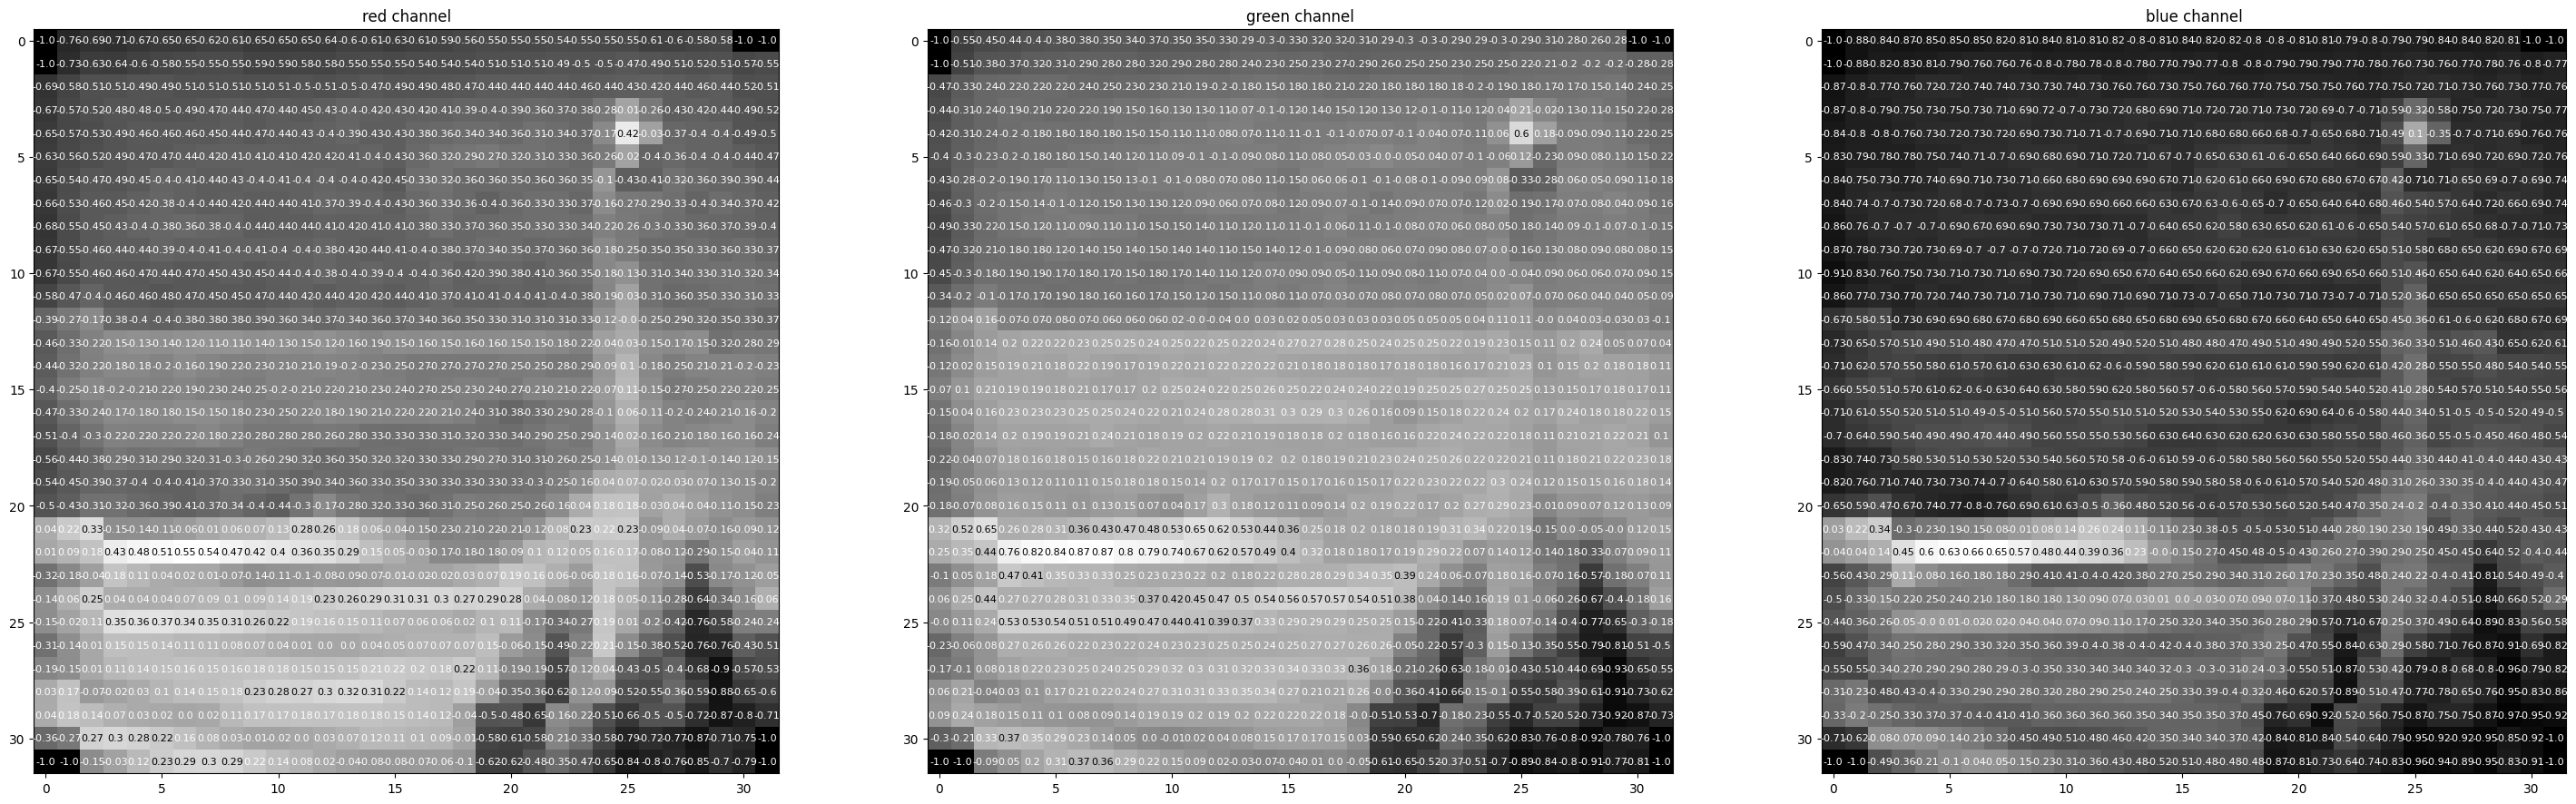

In [5]:
rgb_img = np.squeeze(images[3])
channels = ['red channel', 'green channel', 'blue channel']

fig = plt.figure(figsize = (36, 36)) 
for idx in np.arange(rgb_img.shape[0]):
    ax = fig.add_subplot(1, 3, idx + 1)
    img = rgb_img[idx]
    ax.imshow(img, cmap='gray')
    ax.set_title(channels[idx])
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            val = round(img[x][y],2) if img[x][y] !=0 else 0
            ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center', size=8,
                    color='white' if img[x][y]<thresh else 'black')

---
## Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)

This time, you'll define a CNN architecture. Instead of an MLP, which used linear, fully-connected layers, you'll use the following:
* [Convolutional layers](https://pytorch.org/docs/stable/nn.html#conv2d), which can be thought of as stack of filtered images.
* [Maxpooling layers](https://pytorch.org/docs/stable/nn.html#maxpool2d), which reduce the x-y size of an input, keeping only the most _active_ pixels from the previous layer.
* The usual Linear + Dropout layers to avoid overfitting and produce a 10-dim output.

A network with 2 convolutional layers is shown in the image below and in the code, and you've been given starter code with one convolutional and one maxpooling layer.

<img src='notebook_ims/2_layer_conv.png' height=50% width=50% />

#### TODO: Define a model with multiple convolutional layers, and define the feedforward metwork behavior.

The more convolutional layers you include, the more complex patterns in color and shape a model can detect. It's suggested that your final model include 2 or 3 convolutional layers as well as linear layers + dropout in between to avoid overfitting. 

It's good practice to look at existing research and implementations of related models as a starting point for defining your own models. You may find it useful to look at [this PyTorch classification example](https://github.com/pytorch/tutorials/blob/master/beginner_source/blitz/cifar10_tutorial.py) or [this, more complex Keras example](https://github.com/keras-team/keras/blob/master/examples/cifar10_cnn.py) to help decide on a final structure.

#### Output volume for a convolutional layer

To compute the output size of a given convolutional layer we can perform the following calculation (taken from [Stanford's cs231n course](http://cs231n.github.io/convolutional-networks/#layers)):
> We can compute the spatial size of the output volume as a function of the input volume size (W), the kernel/filter size (F), the stride with which they are applied (S), and the amount of zero padding used (P) on the border. The correct formula for calculating how many neurons define the output_W is given by `(W−F+2P)/S+1`. 

For example for a 7x7 input and a 3x3 filter with stride 1 and pad 0 we would get a 5x5 output. With stride 2 we would get a 3x3 output.

In [6]:
import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # convolutional layer
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        # max pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        ## fully-connected layer
        self.fc1 = nn.Linear(64*4*4, 512)
        self.fc2 = nn.Linear(512, 10)
        # dropout layer (p=0.25)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # add sequence of convolutional and max pooling layers
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        # flatten image input
        x = x.view(x.shape[0], -1)
        # classify using NN
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.log_softmax(self.fc2(x), dim=1)
        return x

# create a complete CNN
model = Net()
print(model)

device = torch.device(device_type)
model.to(device)

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

### Specify [Loss Function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [Optimizer](http://pytorch.org/docs/stable/optim.html)

Decide on a loss and optimization function that is best suited for this classification task. The linked code examples from above, may be a good starting point; [this PyTorch classification example](https://github.com/pytorch/tutorials/blob/master/beginner_source/blitz/cifar10_tutorial.py) or [this, more complex Keras example](https://github.com/keras-team/keras/blob/master/examples/cifar10_cnn.py). Pay close attention to the value for **learning rate** as this value determines how your model converges to a small error.

#### TODO: Define the loss and optimizer and see how these choices change the loss over time.

In [7]:
import torch.optim as optim

# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss().to(device)

# specify optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

---
## Train the Network

Remember to look at how the training and validation loss decreases over time; if the validation loss ever increases it indicates possible overfitting.

In [8]:
# number of epochs to train the model
n_epochs = 30

valid_loss_min = np.Inf # track change in validation loss

for epoch in range(1, n_epochs+1):

    # keep track of training and validation loss
    train_loss = 0.0
    valid_loss = 0.0
    
    ###################
    # train the model #
    ###################
    tic = time.time()
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # move tensors to GPU
        data, target = data.to(device), target.to(device)
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update training loss
        train_loss += loss.item()*data.size(0)
    toc = time.time()
        
    ######################    
    # validate the model #
    ######################
    model.eval()
    for batch_idx, (data, target) in enumerate(valid_loader):
        # move tensors to GPU
        data, target = data.to(device), target.to(device)
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # update average validation loss 
        valid_loss += loss.item()*data.size(0)
    
    # calculate average losses
    train_loss = train_loss/len(train_loader.dataset)
    valid_loss = valid_loss/len(valid_loader.dataset)
        
    # print training/validation statistics 
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f} \tRuntime: {:3d}'.format(
        epoch, train_loss, valid_loss, int(toc-tic)))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model_augmented.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 1.671266 	Validation Loss: 0.359048 	Runtime:   6
Validation loss decreased (inf --> 0.359048).  Saving model ...
Epoch: 2 	Training Loss: 1.324729 	Validation Loss: 0.306099 	Runtime:   6
Validation loss decreased (0.359048 --> 0.306099).  Saving model ...
Epoch: 3 	Training Loss: 1.183504 	Validation Loss: 0.275224 	Runtime:   6
Validation loss decreased (0.306099 --> 0.275224).  Saving model ...
Epoch: 4 	Training Loss: 1.106596 	Validation Loss: 0.260087 	Runtime:   6
Validation loss decreased (0.275224 --> 0.260087).  Saving model ...
Epoch: 5 	Training Loss: 1.043922 	Validation Loss: 0.252173 	Runtime:   6
Validation loss decreased (0.260087 --> 0.252173).  Saving model ...
Epoch: 6 	Training Loss: 0.990486 	Validation Loss: 0.234457 	Runtime:   6
Validation loss decreased (0.252173 --> 0.234457).  Saving model ...
Epoch: 7 	Training Loss: 0.947331 	Validation Loss: 0.222412 	Runtime:   6
Validation loss decreased (0.234457 --> 0.222412).  Saving model .

### Performance Evaluation

**Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060**
 - GPU with 12 data loader workers and 20 batch size take about 5 seconds/epoch.
```
    Epoch: 1 	Training Loss: 1.658556 	Validation Loss: 0.355622 	Runtime:   5
    Validation loss decreased (inf --> 0.355622).  Saving model ...
    Epoch: 2 	Training Loss: 1.355375 	Validation Loss: 0.300816 	Runtime:   5
    Validation loss decreased (0.355622 --> 0.300816).  Saving model ...
    Epoch: 3 	Training Loss: 1.217930 	Validation Loss: 0.277609 	Runtime:   5
    Validation loss decreased (0.300816 --> 0.277609).  Saving model ...
    Epoch: 4 	Training Loss: 1.130721 	Validation Loss: 0.264512 	Runtime:   5
    Validation loss decreased (0.277609 --> 0.264512).  Saving model ...
    Epoch: 5 	Training Loss: 1.062071 	Validation Loss: 0.247655 	Runtime:   5
    Validation loss decreased (0.264512 --> 0.247655).  Saving model ...
    Epoch: 6 	Training Loss: 1.006227 	Validation Loss: 0.230360 	Runtime:   5
    Validation loss decreased (0.247655 --> 0.230360).  Saving model ...
    Epoch: 7 	Training Loss: 0.959791 	Validation Loss: 0.218763 	Runtime:   5
    Validation loss decreased (0.230360 --> 0.218763).  Saving model ...
    Epoch: 8 	Training Loss: 0.920650 	Validation Loss: 0.207980 	Runtime:   5
    Validation loss decreased (0.218763 --> 0.207980).  Saving model ...
    Epoch: 9 	Training Loss: 0.881924 	Validation Loss: 0.203694 	Runtime:   5
    Validation loss decreased (0.207980 --> 0.203694).  Saving model ...
    Epoch: 10 	Training Loss: 0.848833 	Validation Loss: 0.195137 	Runtime:   5
    Validation loss decreased (0.203694 --> 0.195137).  Saving model ...
    Epoch: 11 	Training Loss: 0.820594 	Validation Loss: 0.190080 	Runtime:   5
    Validation loss decreased (0.195137 --> 0.190080).  Saving model ...
    Epoch: 12 	Training Loss: 0.793098 	Validation Loss: 0.182446 	Runtime:   5
    Validation loss decreased (0.190080 --> 0.182446).  Saving model ...
    Epoch: 13 	Training Loss: 0.767743 	Validation Loss: 0.174241 	Runtime:   5
    Validation loss decreased (0.182446 --> 0.174241).  Saving model ...
    Epoch: 14 	Training Loss: 0.742370 	Validation Loss: 0.169503 	Runtime:   5
    Validation loss decreased (0.174241 --> 0.169503).  Saving model ...
    Epoch: 15 	Training Loss: 0.724615 	Validation Loss: 0.169359 	Runtime:   5
    Validation loss decreased (0.169503 --> 0.169359).  Saving model ...
    Epoch: 16 	Training Loss: 0.700951 	Validation Loss: 0.166656 	Runtime:   5
    Validation loss decreased (0.169359 --> 0.166656).  Saving model ...
    Epoch: 17 	Training Loss: 0.680371 	Validation Loss: 0.162590 	Runtime:   5
    Validation loss decreased (0.166656 --> 0.162590).  Saving model ...
    Epoch: 18 	Training Loss: 0.669279 	Validation Loss: 0.162903 	Runtime:   5
    Epoch: 19 	Training Loss: 0.653450 	Validation Loss: 0.157857 	Runtime:   5
    Validation loss decreased (0.162590 --> 0.157857).  Saving model ...
    Epoch: 20 	Training Loss: 0.638819 	Validation Loss: 0.151069 	Runtime:   5
    Validation loss decreased (0.157857 --> 0.151069).  Saving model ...
    Epoch: 21 	Training Loss: 0.625733 	Validation Loss: 0.150708 	Runtime:   5
    Validation loss decreased (0.151069 --> 0.150708).  Saving model ...
    Epoch: 22 	Training Loss: 0.613062 	Validation Loss: 0.145546 	Runtime:   5
    Validation loss decreased (0.150708 --> 0.145546).  Saving model ...
    Epoch: 23 	Training Loss: 0.606970 	Validation Loss: 0.147266 	Runtime:   5
    Epoch: 24 	Training Loss: 0.590389 	Validation Loss: 0.143692 	Runtime:   5
    Validation loss decreased (0.145546 --> 0.143692).  Saving model ...
    Epoch: 25 	Training Loss: 0.585417 	Validation Loss: 0.142155 	Runtime:   5
    Validation loss decreased (0.143692 --> 0.142155).  Saving model ...
    Epoch: 26 	Training Loss: 0.567560 	Validation Loss: 0.139518 	Runtime:   5
    Validation loss decreased (0.142155 --> 0.139518).  Saving model ...
    Epoch: 27 	Training Loss: 0.561952 	Validation Loss: 0.140510 	Runtime:   5
    Epoch: 28 	Training Loss: 0.551652 	Validation Loss: 0.143662 	Runtime:   5
    Epoch: 29 	Training Loss: 0.545229 	Validation Loss: 0.137088 	Runtime:   5
    Validation loss decreased (0.139518 --> 0.137088).  Saving model ...
    Epoch: 30 	Training Loss: 0.538444 	Validation Loss: 0.133751 	Runtime:   5
    Validation loss decreased (0.137088 --> 0.133751).  Saving model ...
```

**Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics**
 - GPU with 24 data loader workers and 20 batch size takes about 6 seconds/epoch using up to 30% of CPU and 40% of GPU utilization.
```
    Epoch: 1 	Training Loss: 1.671266 	Validation Loss: 0.359048 	Runtime:   6
    Validation loss decreased (inf --> 0.359048).  Saving model ...
    Epoch: 2 	Training Loss: 1.324729 	Validation Loss: 0.306099 	Runtime:   6
    Validation loss decreased (0.359048 --> 0.306099).  Saving model ...
    Epoch: 3 	Training Loss: 1.183504 	Validation Loss: 0.275224 	Runtime:   6
    Validation loss decreased (0.306099 --> 0.275224).  Saving model ...
    Epoch: 4 	Training Loss: 1.106596 	Validation Loss: 0.260087 	Runtime:   6
    Validation loss decreased (0.275224 --> 0.260087).  Saving model ...
    Epoch: 5 	Training Loss: 1.043922 	Validation Loss: 0.252173 	Runtime:   6
    Validation loss decreased (0.260087 --> 0.252173).  Saving model ...
    Epoch: 6 	Training Loss: 0.990486 	Validation Loss: 0.234457 	Runtime:   6
    Validation loss decreased (0.252173 --> 0.234457).  Saving model ...
    Epoch: 7 	Training Loss: 0.947331 	Validation Loss: 0.222412 	Runtime:   6
    Validation loss decreased (0.234457 --> 0.222412).  Saving model ...
    Epoch: 8 	Training Loss: 0.904816 	Validation Loss: 0.213722 	Runtime:   6
    Validation loss decreased (0.222412 --> 0.213722).  Saving model ...
    Epoch: 9 	Training Loss: 0.871075 	Validation Loss: 0.199607 	Runtime:   6
    Validation loss decreased (0.213722 --> 0.199607).  Saving model ...
    Epoch: 10 	Training Loss: 0.837748 	Validation Loss: 0.197881 	Runtime:   6
    Validation loss decreased (0.199607 --> 0.197881).  Saving model ...
    Epoch: 11 	Training Loss: 0.810454 	Validation Loss: 0.192274 	Runtime:   6
    Validation loss decreased (0.197881 --> 0.192274).  Saving model ...
    Epoch: 12 	Training Loss: 0.782262 	Validation Loss: 0.182954 	Runtime:   6
    Validation loss decreased (0.192274 --> 0.182954).  Saving model ...
    Epoch: 13 	Training Loss: 0.758529 	Validation Loss: 0.182260 	Runtime:   6
    Validation loss decreased (0.182954 --> 0.182260).  Saving model ...
    Epoch: 14 	Training Loss: 0.735183 	Validation Loss: 0.175507 	Runtime:   6
    Validation loss decreased (0.182260 --> 0.175507).  Saving model ...
    Epoch: 15 	Training Loss: 0.715642 	Validation Loss: 0.168426 	Runtime:   6
    Validation loss decreased (0.175507 --> 0.168426).  Saving model ...
    Epoch: 16 	Training Loss: 0.699215 	Validation Loss: 0.168452 	Runtime:   6
    Epoch: 17 	Training Loss: 0.680303 	Validation Loss: 0.161510 	Runtime:   6
    Validation loss decreased (0.168426 --> 0.161510).  Saving model ...
    Epoch: 18 	Training Loss: 0.665702 	Validation Loss: 0.162079 	Runtime:   6
    Epoch: 19 	Training Loss: 0.645959 	Validation Loss: 0.160183 	Runtime:   6
    Validation loss decreased (0.161510 --> 0.160183).  Saving model ...
    Epoch: 20 	Training Loss: 0.635550 	Validation Loss: 0.155674 	Runtime:   6
    Validation loss decreased (0.160183 --> 0.155674).  Saving model ...
    Epoch: 21 	Training Loss: 0.623075 	Validation Loss: 0.152715 	Runtime:   6
    Validation loss decreased (0.155674 --> 0.152715).  Saving model ...
    Epoch: 22 	Training Loss: 0.611067 	Validation Loss: 0.148012 	Runtime:   6
    Validation loss decreased (0.152715 --> 0.148012).  Saving model ...
    Epoch: 23 	Training Loss: 0.597184 	Validation Loss: 0.147216 	Runtime:   6
    Validation loss decreased (0.148012 --> 0.147216).  Saving model ...
    Epoch: 24 	Training Loss: 0.588526 	Validation Loss: 0.145777 	Runtime:   6
    Validation loss decreased (0.147216 --> 0.145777).  Saving model ...
    Epoch: 25 	Training Loss: 0.579856 	Validation Loss: 0.145023 	Runtime:   6
    Validation loss decreased (0.145777 --> 0.145023).  Saving model ...
    Epoch: 26 	Training Loss: 0.568686 	Validation Loss: 0.146456 	Runtime:   6
    Epoch: 27 	Training Loss: 0.565247 	Validation Loss: 0.141463 	Runtime:   6
    Validation loss decreased (0.145023 --> 0.141463).  Saving model ...
    Epoch: 28 	Training Loss: 0.558390 	Validation Loss: 0.141524 	Runtime:   6
    Epoch: 29 	Training Loss: 0.545386 	Validation Loss: 0.138406 	Runtime:   6
    Validation loss decreased (0.141463 --> 0.138406).  Saving model ...
    Epoch: 30 	Training Loss: 0.536557 	Validation Loss: 0.132341 	Runtime:   6
    Validation loss decreased (0.138406 --> 0.132341).  Saving model ...
```
 - Idle power consumption for GPU is 40W and CPU cores only is 1W with CPU total of 10W.
 - Training on GPU power consumption for GPU is 90W and CPU cores only is 30W with CPU total of 40W.

###  Load the Model with the Lowest Validation Loss

In [9]:
model.load_state_dict(torch.load('model_augmented.pt', weights_only=False))

<All keys matched successfully>

---
## Test the Trained Network

Test your trained model on previously unseen data! A "good" result will be a CNN that gets around 70% (or more, try your best!) accuracy on these test images.

In [10]:
# track test loss
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()
# iterate over test data
for batch_idx, (data, target) in enumerate(test_loader):
    # move tensors to GPU if available
    data, target = data.to(device), target.to(device)
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(data)
    # calculate the batch loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)    
    # compare predictions to true label
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.to("cpu").numpy()) 
    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# average test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.681251

Test Accuracy of airplane: 79% (799/1000)
Test Accuracy of automobile: 88% (887/1000)
Test Accuracy of  bird: 63% (632/1000)
Test Accuracy of   cat: 56% (561/1000)
Test Accuracy of  deer: 72% (728/1000)
Test Accuracy of   dog: 68% (685/1000)
Test Accuracy of  frog: 83% (832/1000)
Test Accuracy of horse: 82% (828/1000)
Test Accuracy of  ship: 85% (857/1000)
Test Accuracy of truck: 82% (825/1000)

Test Accuracy (Overall): 76% (7634/10000)


### Visualize Sample Test Results

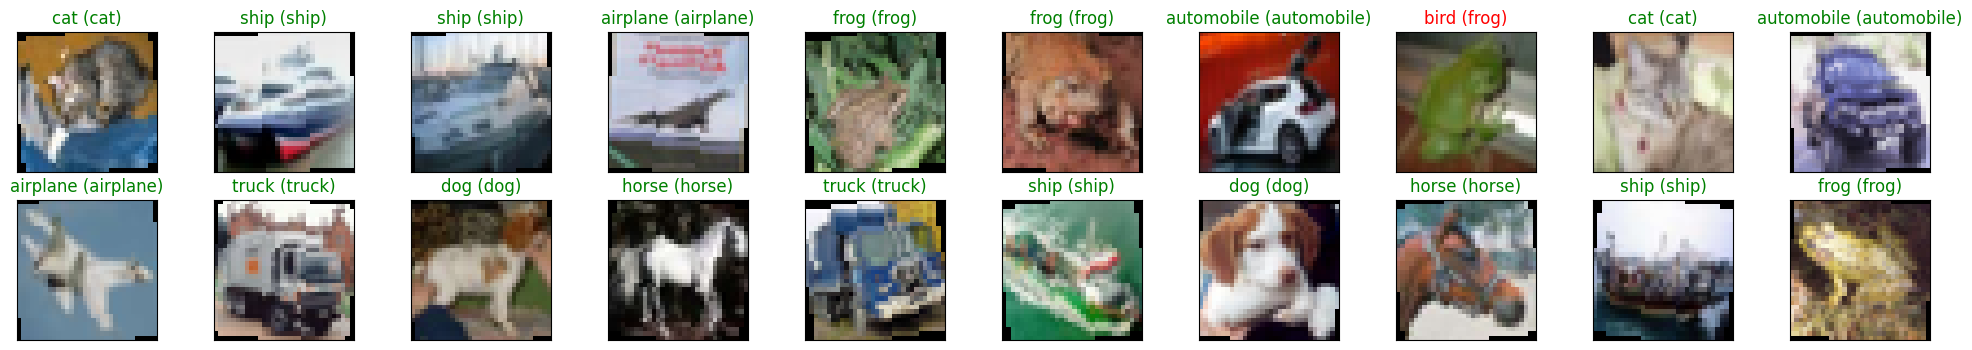

In [11]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images.numpy()

# move model GPU if available
images = images.to(device)

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds_tensor = torch.max(output, 1)
preds = np.squeeze(preds_tensor.to("cpu").numpy())

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx].to("cpu"))
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=("green" if preds[idx]==labels[idx].item() else "red"))